# Checkpoint Reconstruction Analysis

TODOs answered here:

1. What is the relationship between sequence length and reconstruction loss?
2. How does the reconstruction loss evolve over epochs for different sequence lengths?
3. Are there some amino acids that are more likely to be reconstructed incorrectly?

`outputs/output_results.csv` contains per-example `token_accuracy`, but not per-example cross-entropy loss or epoch. This notebook uses `1 - token_accuracy` as a per-example reconstruction-error proxy for questions 1 and 3. Question 2 can only be answered by sequence-length bin if per-epoch reconstruction outputs are saved; the notebook plots available global history now and includes a guarded cell for future per-epoch length-binned files.

In [20]:
from pathlib import Path
import json
import os

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "outputs" / "output_results.csv").exists():
    for parent in Path.cwd().parents:
        if (parent / "outputs" / "output_results.csv").exists():
            PROJECT_ROOT = parent
            break

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib_cache"))
(PROJECT_ROOT / ".matplotlib_cache").mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

RESULTS_PATH = PROJECT_ROOT / "outputs" / "output_results.csv"
HISTORY_DIR = PROJECT_ROOT / "history"
print(f"Project root: {PROJECT_ROOT}")
print(f"Results CSV: {RESULTS_PATH}")

Project root: /Users/josh/GWU/protein-sequence-augmentation
Results CSV: /Users/josh/GWU/protein-sequence-augmentation/outputs/output_results.csv


In [21]:
results = pd.read_csv(RESULTS_PATH)
numeric_cols = ["target_length", "predicted_length", "token_accuracy"]
results[numeric_cols] = results[numeric_cols].apply(pd.to_numeric, errors="coerce")
results = results.dropna(subset=numeric_cols).copy()

# output_results.csv does not include cross-entropy loss, so this is a token-error proxy.
results["reconstruction_error"] = 1.0 - results["token_accuracy"]
results["length_delta"] = results["predicted_length"] - results["target_length"]
results["abs_length_delta"] = results["length_delta"].abs()
results["length_bin"] = pd.qcut(
    results["target_length"],
    q=4,
    labels=["short", "medium-short", "medium-long", "long"],
    duplicates="drop",
)

summary = results[["target_length", "predicted_length", "token_accuracy", "reconstruction_error", "length_delta"]].describe()
display(summary)
display(results.groupby("length_bin", observed=True)[["target_length", "token_accuracy", "reconstruction_error", "abs_length_delta"]].agg(["count", "mean", "median", "std"]))

,target_length,predicted_length,token_accuracy,reconstruction_error,length_delta
count,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000
mean,296.329165,298.673837,0.487402,0.512598,2.344672
std,185.184135,191.879416,0.162991,0.162991,36.374550
min,34.000000,34.000000,0.149875,0.075472,-11.000000
25%,159.000000,159.500000,0.361310,0.386622,0.000000
50%,260.000000,260.000000,0.462687,0.537313,0.000000
75%,379.000000,379.000000,0.613379,0.638690,0.000000
max,1200.000000,1201.000000,0.924528,0.850125,1062.000000


target_length                                token_accuracy  \
                     count        mean median         std          count   
length_bin                                                                 
short                  502  116.683267  121.0   28.437509            502   
medium-short           501  210.808383  211.0   29.545748            501   
medium-long            500  315.848000  312.0   34.111818            500   
long                   496  544.854839  482.0  182.044747            496   

                                           reconstruction_error            \
                  mean    median       std                count      mean   
length_bin                                                                  
short         0.708139  0.703337  0.076444                  502  0.291861   
medium-short  0.530520  0.528037  0.058820                  501  0.469480   
medium-long   0.411690  0.410262  0.039663                  500  0.588310   
long          0.296764  0.304670  0.052281                  496  0.703236   

                                 abs_length_delta                              
                median       std            count      mean median        std  
length_bin                                                                     
short         0.296663  0.076444              502  2.292829    0.0  47.393161  
medium-short  0.471963  0.058820              501  0.455090    0.0   0.718665  
medium-long   0.589738  0.039663              500  2.694000    1.0  40.593547  
long          0.695331  0.052281              496  7.179435    1.0  36.921731

## 1. Sequence Length vs Reconstruction Error

The scatter/LOWESS plot shows whether longer sequences tend to have higher token reconstruction error. The boxplot compares the same error proxy across target-length quartiles.

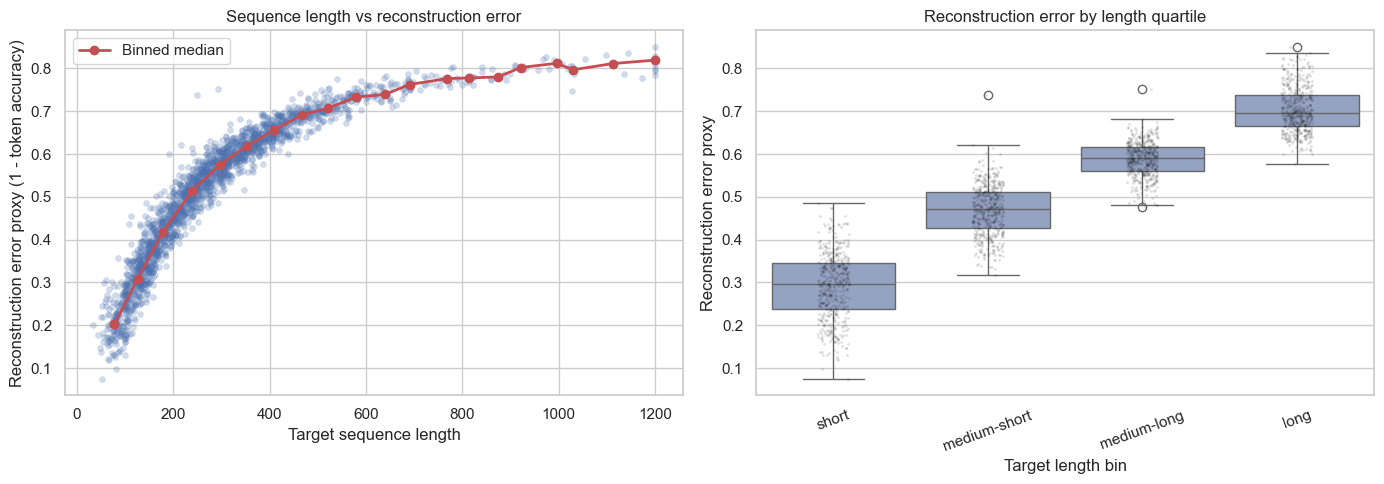

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=results,
    x="target_length",
    y="reconstruction_error",
    alpha=0.25,
    s=18,
    edgecolor=None,
    ax=axes[0],
)

trend = (
    results.assign(length_window=pd.cut(results["target_length"], bins=20))
    .groupby("length_window", observed=True)
    .agg(
        target_length=("target_length", "median"),
        reconstruction_error=("reconstruction_error", "median"),
    )
    .dropna()
)

axes[0].plot(
    trend["target_length"],
    trend["reconstruction_error"],
    color="#c44e52",
    linewidth=2,
    marker="o",
    label="Binned median",
)
axes[0].legend()
axes[0].set_title("Sequence length vs reconstruction error")
axes[0].set_xlabel("Target sequence length")
axes[0].set_ylabel("Reconstruction error proxy (1 - token accuracy)")

sns.boxplot(data=results, x="length_bin", y="reconstruction_error", ax=axes[1], color="#8da0cb")
sns.stripplot(data=results, x="length_bin", y="reconstruction_error", ax=axes[1], color="black", alpha=0.12, size=2)
axes[1].set_title("Reconstruction error by length quartile")
axes[1].set_xlabel("Target length bin")
axes[1].set_ylabel("Reconstruction error proxy")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [23]:
spearman_r, spearman_p = stats.spearmanr(results["target_length"], results["reconstruction_error"])
pearson_r, pearson_p = stats.pearsonr(results["target_length"], results["reconstruction_error"])

groups = [g["reconstruction_error"].to_numpy() for _, g in results.groupby("length_bin", observed=True)]
kruskal_h, kruskal_p = stats.kruskal(*groups)

q1_stats = pd.DataFrame(
    [
        {"test": "Spearman length vs error", "statistic": spearman_r, "p_value": spearman_p},
        {"test": "Pearson length vs error", "statistic": pearson_r, "p_value": pearson_p},
        {"test": "Kruskal-Wallis error across length bins", "statistic": kruskal_h, "p_value": kruskal_p},
    ]
)
display(q1_stats)

alpha = 0.05
print(
    f"Spearman rho={spearman_r:.3f}, p={spearman_p:.3g}. "
    f"Length-bin Kruskal-Wallis p={kruskal_p:.3g}. "
    f"At alpha={alpha}, the length/error association is "
    f"{'statistically detectable' if spearman_p < alpha else 'not statistically detectable'} in this output file."
)

,test,statistic,p_value
0,Spearman length vs error,0.978926,0.0
1,Pearson length vs error,0.862969,0.0
2,Kruskal-Wallis error across length bins,1797.847084,0.0


Spearman rho=0.979, p=0. Length-bin Kruskal-Wallis p=0. At alpha=0.05, the length/error association is statistically detectable in this output file.


## 2. Amino-Acid Specific Reconstruction Errors

This section compares each target amino acid to the predicted amino acid at the same decoder position. If the prediction ended early, remaining target positions are counted as incorrect. This matches the token-level reconstruction framing used by `test_autoencoder.py`.

In [24]:
aa_rows = []
confusion_rows = []

for row in results.itertuples(index=False):
    target = str(row.target_sequence)
    predicted = str(row.predicted_sequence)
    for pos, target_aa in enumerate(target):
        predicted_aa = predicted[pos] if pos < len(predicted) else "<END>"
        correct = target_aa == predicted_aa
        aa_rows.append({"target_aa": target_aa, "correct": correct, "position": pos, "example_index": row.example_index})
        confusion_rows.append({"target_aa": target_aa, "predicted_aa": predicted_aa})

aa_df = pd.DataFrame(aa_rows)
aa_summary = (
    aa_df.groupby("target_aa")
    .agg(n_tokens=("correct", "size"), n_incorrect=("correct", lambda s: (~s).sum()), accuracy=("correct", "mean"))
    .assign(error_rate=lambda d: 1.0 - d["accuracy"])
    .sort_values("error_rate", ascending=False)
)
display(aa_summary)

,n_tokens,n_incorrect,accuracy,error_rate
target_aa,,,,
L,54780,37355,0.318091,0.681909
A,47069,31791,0.324587,0.675413
G,39276,26203,0.332850,0.667150
V,37944,25275,0.333887,0.666113
E,41705,27253,0.346529,0.653471
K,34686,22592,0.348671,0.651329
R,33105,21152,0.361063,0.638937
I,32841,20604,0.372614,0.627386
T,31469,19169,0.390861,0.609139


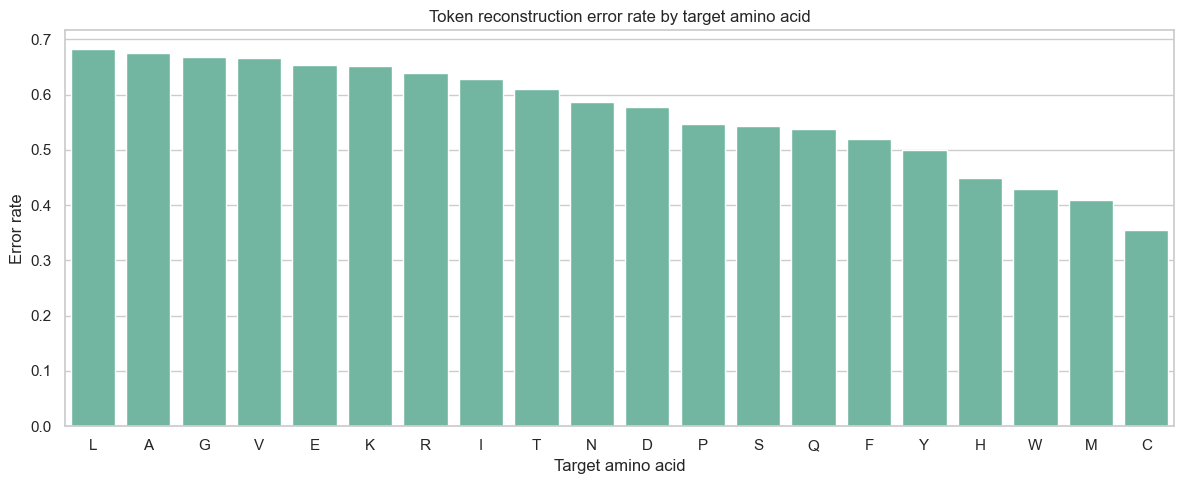

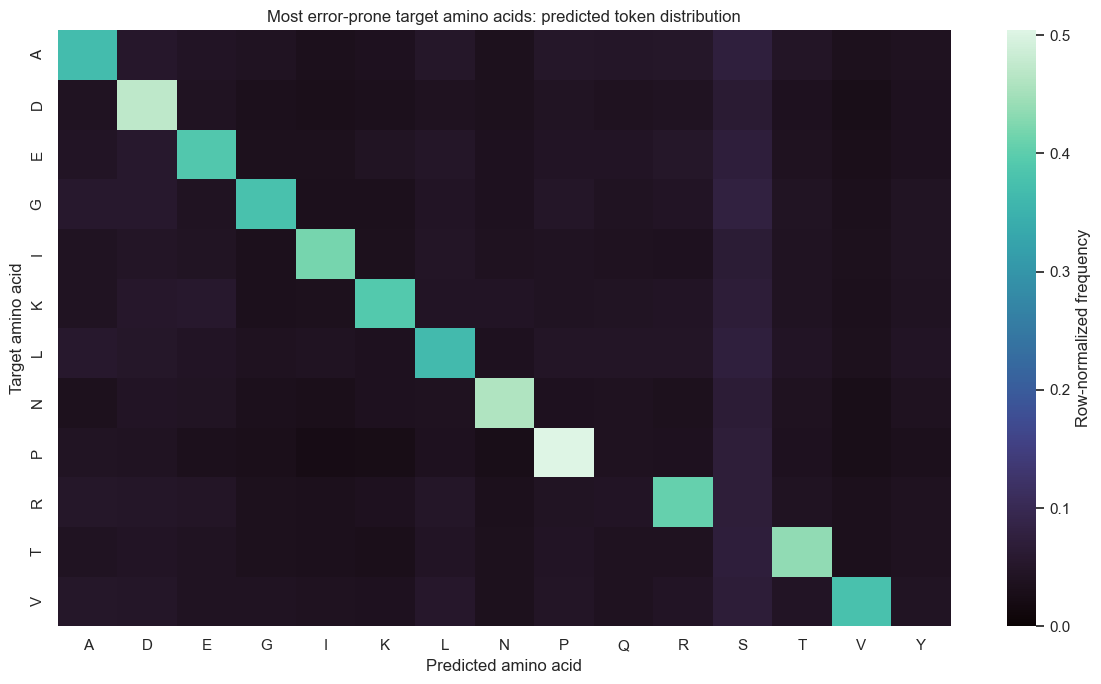

In [25]:
plt.figure(figsize=(12, 5))
plot_df = aa_summary.reset_index().sort_values("error_rate", ascending=False)
sns.barplot(data=plot_df, x="target_aa", y="error_rate", color="#66c2a5")
plt.title("Token reconstruction error rate by target amino acid")
plt.xlabel("Target amino acid")
plt.ylabel("Error rate")
plt.tight_layout()
plt.show()

top_targets = aa_summary.head(12).index.tolist()
confusion_df = pd.DataFrame(confusion_rows)
confusion_top = confusion_df[confusion_df["target_aa"].isin(top_targets)].copy()
top_predictions = confusion_top["predicted_aa"].value_counts().head(15).index.tolist()
confusion_top = confusion_top[confusion_top["predicted_aa"].isin(top_predictions)]
confusion_matrix = pd.crosstab(confusion_top["target_aa"], confusion_top["predicted_aa"], normalize="index")

plt.figure(figsize=(12, 7))
sns.heatmap(confusion_matrix, cmap="mako", vmin=0, vmax=confusion_matrix.to_numpy().max(), cbar_kws={"label": "Row-normalized frequency"})
plt.title("Most error-prone target amino acids: predicted token distribution")
plt.xlabel("Predicted amino acid")
plt.ylabel("Target amino acid")
plt.tight_layout()
plt.show()

In [26]:
contingency = pd.crosstab(aa_df["target_aa"], aa_df["correct"])
chi2, chi2_p, dof, expected = stats.chi2_contingency(contingency)

overall_error = 1.0 - aa_df["correct"].mean()
aa_summary_for_tests = aa_summary.copy()
aa_summary_for_tests["binom_p_value"] = [
    stats.binomtest(int(row.n_incorrect), int(row.n_tokens), overall_error, alternative="greater").pvalue
    for row in aa_summary_for_tests.itertuples()
]
aa_summary_for_tests["bonferroni_p_value"] = np.minimum(aa_summary_for_tests["binom_p_value"] * len(aa_summary_for_tests), 1.0)

print(f"Chi-square test of amino acid vs correctness: chi2={chi2:.2f}, dof={dof}, p={chi2_p:.3g}")
print(f"Overall token error rate from aligned target positions: {overall_error:.3f}")
display(aa_summary_for_tests.sort_values("bonferroni_p_value").head(10))

Chi-square test of amino acid vs correctness: chi2=14789.07, dof=19, p=0
Overall token error rate from aligned target positions: 0.602


,n_tokens,n_incorrect,accuracy,error_rate,binom_p_value,bonferroni_p_value
target_aa,,,,,,
L,54780,37355,0.318091,0.681909,0.000000e+00,0.000000e+00
A,47069,31791,0.324587,0.675413,3.243234e-241,6.486468e-240
G,39276,26203,0.332850,0.667150,4.784770e-159,9.569540e-158
V,37944,25275,0.333887,0.666113,6.410610e-149,1.282122e-147
E,41705,27253,0.346529,0.653471,5.162455e-106,1.032491e-104
K,34686,22592,0.348671,0.651329,1.691849e-81,3.383699e-80
R,33105,21152,0.361063,0.638937,1.168853e-44,2.337706e-43
I,32841,20604,0.372614,0.627386,4.138478e-22,8.276956e-21
T,31469,19169,0.390861,0.609139,2.996585e-03,5.993169e-02


## 3. Position-Wise Reconstruction Errors

This analysis checks whether the decoder gets worse as it moves through a sequence. Absolute position shows whether errors grow at large token indices. Relative position shows whether errors are concentrated near the beginning, middle, or end of proteins regardless of their total length.

In [27]:
position_rows = []

for row in results.itertuples(index=False):
    target = str(row.target_sequence)
    predicted = str(row.predicted_sequence)
    target_len = len(target)
    if target_len == 0:
        continue

    for pos, target_aa in enumerate(target):
        predicted_aa = predicted[pos] if pos < len(predicted) else "<END>"
        position_rows.append(
            {
                "example_index": row.example_index,
                "absolute_position": pos + 1,
                "relative_position": (pos + 1) / target_len,
                "target_length": target_len,
                "length_bin": row.length_bin,
                "target_aa": target_aa,
                "predicted_aa": predicted_aa,
                "correct": target_aa == predicted_aa,
                "error": int(target_aa != predicted_aa),
            }
        )

position_df = pd.DataFrame(position_rows)
position_df["absolute_position_bin"] = pd.cut(position_df["absolute_position"], bins=40)
position_df["relative_position_bin"] = pd.cut(
    position_df["relative_position"],
    bins=np.linspace(0, 1, 11),
    include_lowest=True,
)

absolute_position_summary = (
    position_df.groupby("absolute_position_bin", observed=True)
    .agg(
        position_midpoint=("absolute_position", "median"),
        n_tokens=("error", "size"),
        error_rate=("error", "mean"),
    )
    .query("n_tokens >= 50")
    .reset_index(drop=True)
)

relative_position_summary = (
    position_df.groupby(["relative_position_bin", "length_bin"], observed=True)
    .agg(
        relative_position_midpoint=("relative_position", "median"),
        n_tokens=("error", "size"),
        error_rate=("error", "mean"),
    )
    .reset_index()
)

display(absolute_position_summary.head())
display(relative_position_summary.head())

,position_midpoint,n_tokens,error_rate
0,15.5,59970,0.314024
1,45.0,59852,0.503108
2,75.0,58404,0.519656
3,105.0,54817,0.546272
4,135.0,49804,0.574693


,relative_position_bin,length_bin,relative_position_midpoint,n_tokens,error_rate
0,"(-0.001, 0.1]",long,0.050514,26814,0.505333
1,"(-0.001, 0.1]",medium-long,0.050898,15569,0.333804
2,"(-0.001, 0.1]",medium-short,0.051282,10338,0.240956
3,"(-0.001, 0.1]",short,0.052239,5627,0.159765
4,"(0.1, 0.2]",long,0.150094,27046,0.682097


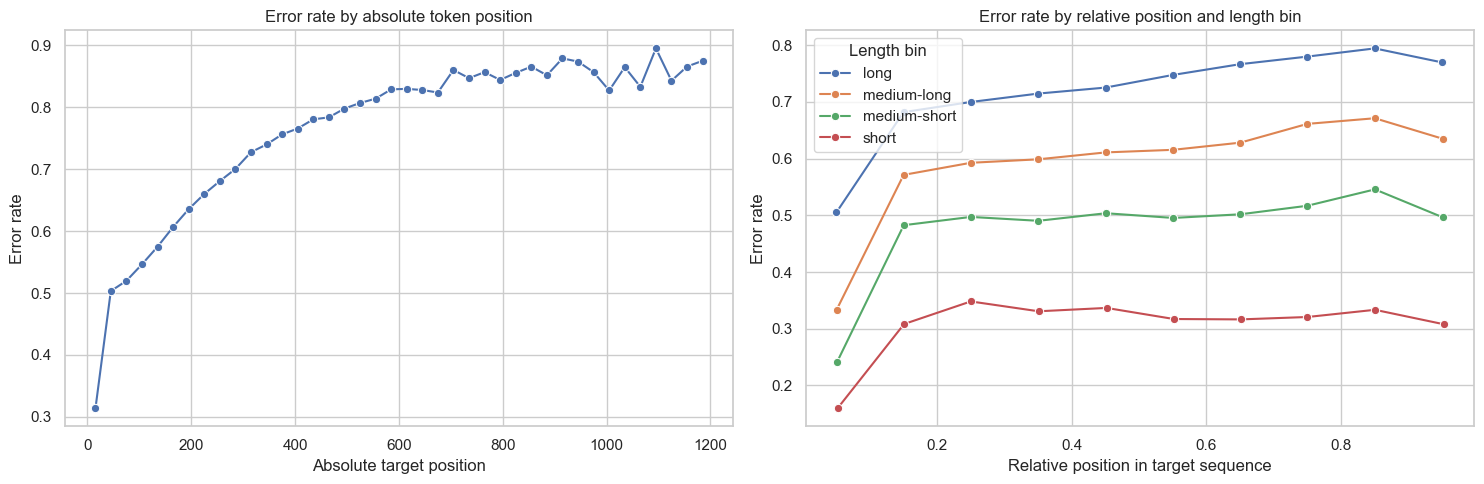

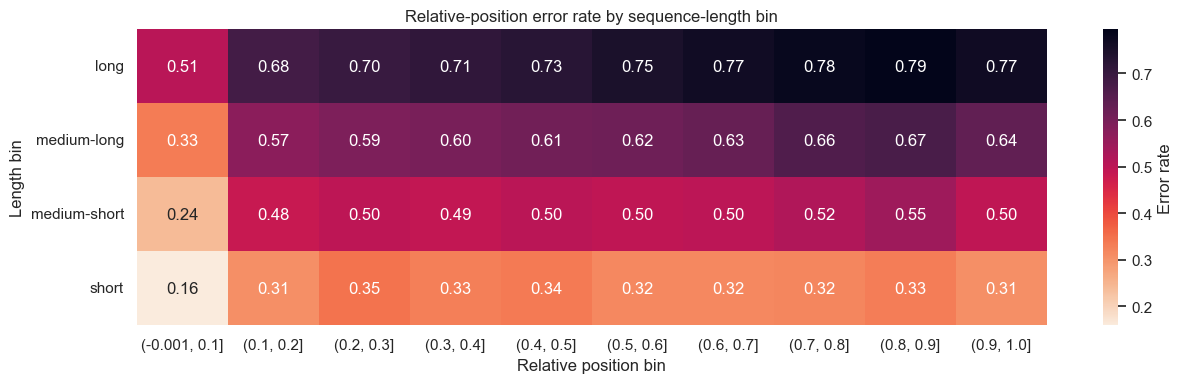

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(
    data=absolute_position_summary,
    x="position_midpoint",
    y="error_rate",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Error rate by absolute token position")
axes[0].set_xlabel("Absolute target position")
axes[0].set_ylabel("Error rate")

sns.lineplot(
    data=relative_position_summary,
    x="relative_position_midpoint",
    y="error_rate",
    hue="length_bin",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Error rate by relative position and length bin")
axes[1].set_xlabel("Relative position in target sequence")
axes[1].set_ylabel("Error rate")
axes[1].legend(title="Length bin")

plt.tight_layout()
plt.show()

position_heatmap = relative_position_summary.pivot(
    index="length_bin",
    columns="relative_position_bin",
    values="error_rate",
)

plt.figure(figsize=(13, 4))
sns.heatmap(position_heatmap, cmap="rocket_r", annot=True, fmt=".2f", cbar_kws={"label": "Error rate"})
plt.title("Relative-position error rate by sequence-length bin")
plt.xlabel("Relative position bin")
plt.ylabel("Length bin")
plt.tight_layout()
plt.show()

In [29]:
abs_pos_rho, abs_pos_p = stats.spearmanr(position_df["absolute_position"], position_df["error"])
rel_pos_rho, rel_pos_p = stats.spearmanr(position_df["relative_position"], position_df["error"])

relative_groups = [
    group["error"].to_numpy()
    for _, group in position_df.groupby("relative_position_bin", observed=True)
]
rel_kruskal_h, rel_kruskal_p = stats.kruskal(*relative_groups)

position_tests = pd.DataFrame(
    [
        {"test": "Spearman absolute position vs error", "statistic": abs_pos_rho, "p_value": abs_pos_p},
        {"test": "Spearman relative position vs error", "statistic": rel_pos_rho, "p_value": rel_pos_p},
        {"test": "Kruskal-Wallis error across relative-position bins", "statistic": rel_kruskal_h, "p_value": rel_kruskal_p},
    ]
)
display(position_tests)

print(
    f"Absolute-position Spearman rho={abs_pos_rho:.3f}, p={abs_pos_p:.3g}. "
    f"Relative-position Spearman rho={rel_pos_rho:.3f}, p={rel_pos_p:.3g}."
)

,test,statistic,p_value
0,Spearman absolute position vs error,0.274133,0.0
1,Spearman relative position vs error,0.120125,0.0
2,Kruskal-Wallis error across relative-position ...,14950.106447,0.0


Absolute-position Spearman rho=0.274, p=0. Relative-position Spearman rho=0.120, p=0.


## 4. Length and EOS-Style Failure Analysis

`output_results.csv` stores decoded string lengths, not explicit EOS probabilities. Still, predicted length vs target length is a useful proxy for EOS/stop behavior. If high-error examples also have large length errors, the model may be struggling with when to stop rather than only which amino acid to emit.

In [30]:
length_error_df = results.copy()
length_error_df["length_error_type"] = np.select(
    [
        length_error_df["length_delta"] < 0,
        length_error_df["length_delta"] == 0,
        length_error_df["length_delta"] > 0,
    ],
    ["shorter_than_target", "exact_length", "longer_than_target"],
    default="unknown",
)

length_error_df["large_length_error"] = (
    length_error_df["abs_length_delta"] >= 0.10 * length_error_df["target_length"]
)

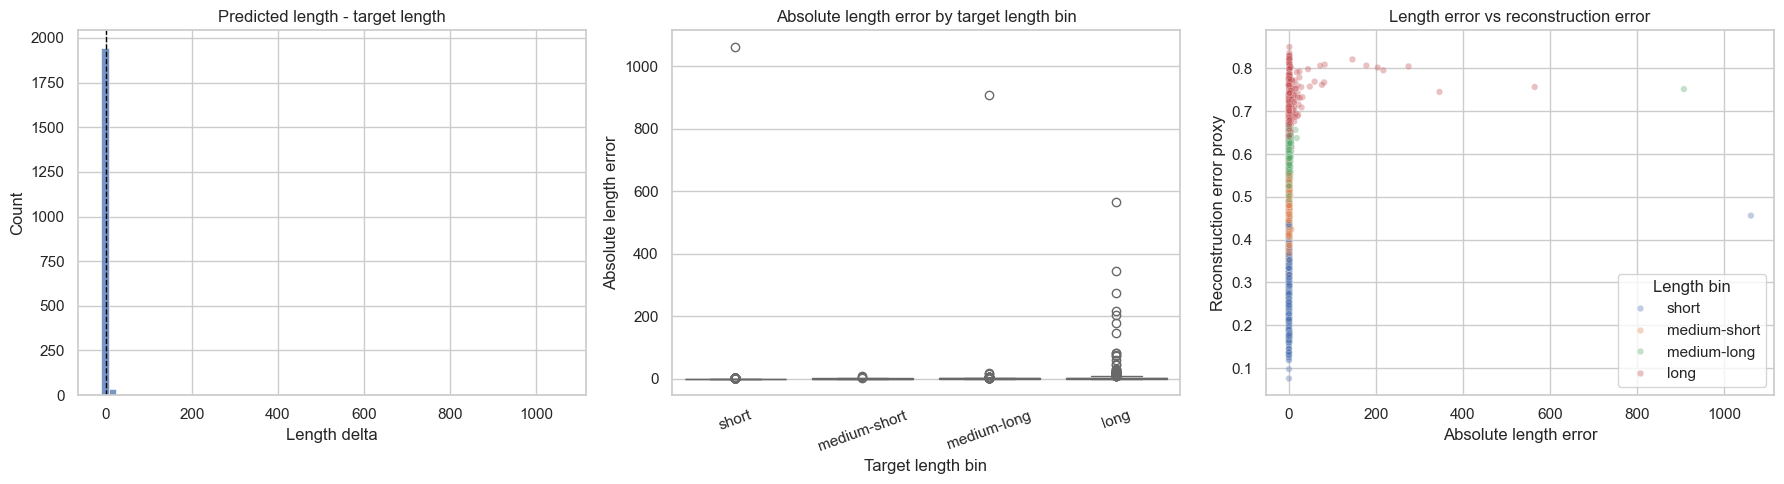

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=length_error_df, x="length_delta", bins=60, ax=axes[0])
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Predicted length - target length")
axes[0].set_xlabel("Length delta")

sns.boxplot(data=length_error_df, x="length_bin", y="abs_length_delta", ax=axes[1], color="#fc8d62")
axes[1].set_title("Absolute length error by target length bin")
axes[1].set_xlabel("Target length bin")
axes[1].set_ylabel("Absolute length error")
axes[1].tick_params(axis="x", rotation=20)

sns.scatterplot(
    data=length_error_df,
    x="abs_length_delta",
    y="reconstruction_error",
    hue="length_bin",
    alpha=0.35,
    s=22,
    ax=axes[2],
)
axes[2].set_title("Length error vs reconstruction error")
axes[2].set_xlabel("Absolute length error")
axes[2].set_ylabel("Reconstruction error proxy")
axes[2].legend(title="Length bin")

plt.tight_layout()
plt.show()

In [32]:
length_delta_rho, length_delta_p = stats.spearmanr(length_error_df["target_length"], length_error_df["length_delta"])
abs_length_error_rho, abs_length_error_p = stats.spearmanr(length_error_df["abs_length_delta"], length_error_df["reconstruction_error"])

length_type_groups = [
    group["reconstruction_error"].to_numpy()
    for _, group in length_error_df.groupby("length_error_type", observed=True)
]
length_type_h, length_type_p = stats.kruskal(*length_type_groups)

length_tests = pd.DataFrame(
    [
        {"test": "Spearman target length vs length delta", "statistic": length_delta_rho, "p_value": length_delta_p},
        {"test": "Spearman absolute length error vs reconstruction error", "statistic": abs_length_error_rho, "p_value": abs_length_error_p},
        {"test": "Kruskal-Wallis reconstruction error across length-error types", "statistic": length_type_h, "p_value": length_type_p},
    ]
)
display(length_tests)

print(
    f"Abs length error vs reconstruction error: rho={abs_length_error_rho:.3f}, p={abs_length_error_p:.3g}. "
    "A strong positive value means length-control failures explain a meaningful part of the reconstruction problem."
)

,test,statistic,p_value
0,Spearman target length vs length delta,0.111911,5.270729e-07
1,Spearman absolute length error vs reconstructi...,0.473539,2.941841e-112
2,Kruskal-Wallis reconstruction error across len...,413.619284,1.526559e-90


Abs length error vs reconstruction error: rho=0.474, p=2.94e-112. A strong positive value means length-control failures explain a meaningful part of the reconstruction problem.


## 5. High-Rate Amino-Acid Confusions

This section asks which target amino acids are most often decoded as specific other amino acids. The heatmap is row-normalized by target amino acid, so each value means: among all true tokens of this amino acid, what fraction were decoded as the column amino acid? The table below focuses on off-diagonal mistakes only.

In [33]:
standard_aas = list("ACDEFGHIKLMNPQRSTVWY")

if "aa_df" not in globals() or "predicted_aa" not in aa_df.columns:
    aa_rows = []
    for row in results.itertuples(index=False):
        target = str(row.target_sequence)
        predicted = str(row.predicted_sequence)
        for pos, target_aa in enumerate(target):
            predicted_aa = predicted[pos] if pos < len(predicted) else "<END>"
            aa_rows.append(
                {
                    "target_aa": target_aa,
                    "predicted_aa": predicted_aa,
                    "correct": target_aa == predicted_aa,
                }
            )
    aa_df = pd.DataFrame(aa_rows)

aa_confusions = aa_df[aa_df["target_aa"].isin(standard_aas)].copy()
target_counts = aa_confusions["target_aa"].value_counts().rename("target_count")
incorrect_counts = (
    aa_confusions[aa_confusions["target_aa"] != aa_confusions["predicted_aa"]]
    .groupby("target_aa")
    .size()
    .rename("target_error_count")
)

pair_counts = (
    aa_confusions[aa_confusions["target_aa"] != aa_confusions["predicted_aa"]]
    .groupby(["target_aa", "predicted_aa"])
    .size()
    .rename("n_confusions")
    .reset_index()
    .merge(target_counts, left_on="target_aa", right_index=True)
    .merge(incorrect_counts, left_on="target_aa", right_index=True)
)
pair_counts["rate_among_target_tokens"] = pair_counts["n_confusions"] / pair_counts["target_count"]
pair_counts["share_of_target_errors"] = pair_counts["n_confusions"] / pair_counts["target_error_count"]
pair_counts["confusion_pair"] = pair_counts["target_aa"] + " -> " + pair_counts["predicted_aa"]

aa_pair_counts = pair_counts[pair_counts["predicted_aa"].isin(standard_aas)].copy()
top_confusion_pairs = aa_pair_counts.sort_values(
    ["rate_among_target_tokens", "n_confusions"],
    ascending=False,
).head(25)

display(top_confusion_pairs[[
    "confusion_pair",
    "n_confusions",
    "target_count",
    "target_error_count",
    "rate_among_target_tokens",
    "share_of_target_errors",
]])

,confusion_pair,n_confusions,target_count,target_error_count,rate_among_target_tokens,share_of_target_errors
115,G -> S,2724,39276,26203,0.069355,0.103958
15,A -> S,3037,47069,31791,0.064522,0.095530
336,T -> S,2022,31469,19169,0.064254,0.105483
75,E -> S,2669,41705,27253,0.063997,0.097934
195,L -> S,3483,54780,37355,0.063582,0.093241
255,P -> S,1735,27438,15024,0.063233,0.115482
295,R -> S,2068,33105,21152,0.062468,0.097769
235,N -> S,1487,24664,14461,0.060290,0.102828
175,K -> S,2090,34686,22592,0.060255,0.092511
356,V -> S,2284,37944,25275,0.060194,0.090366


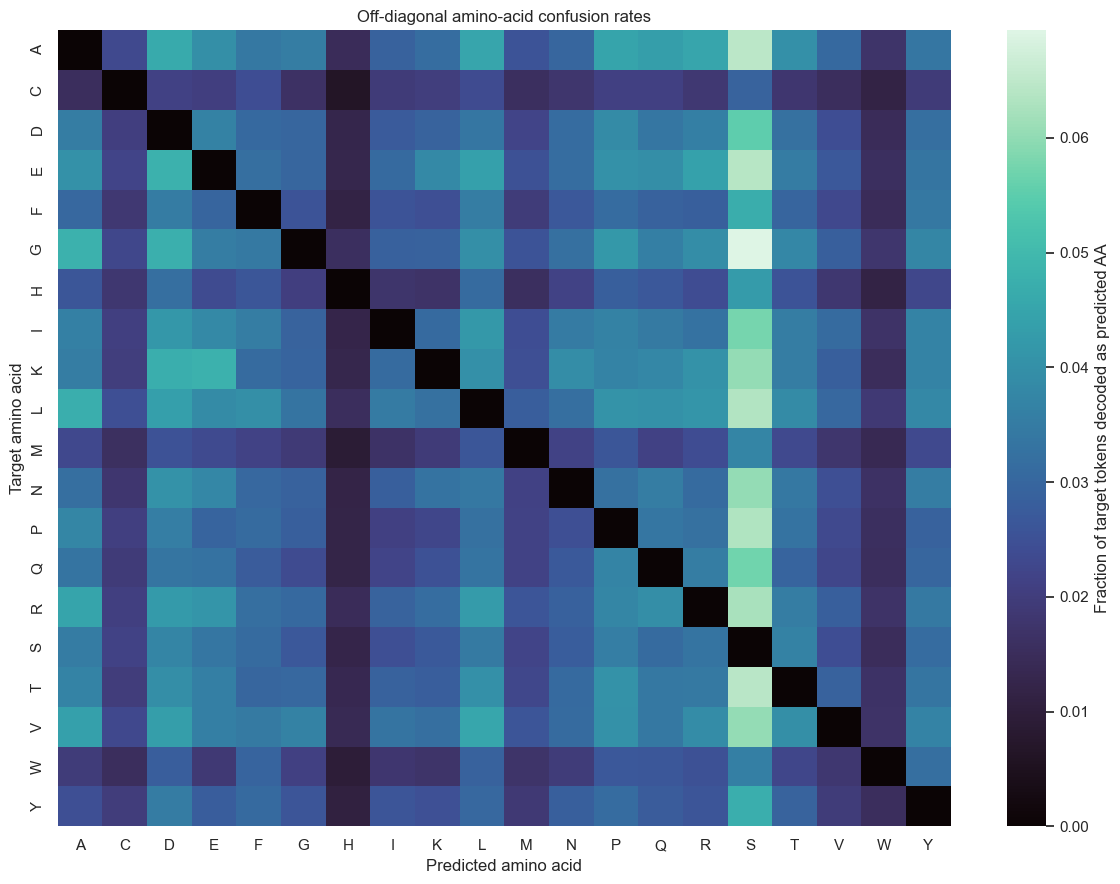

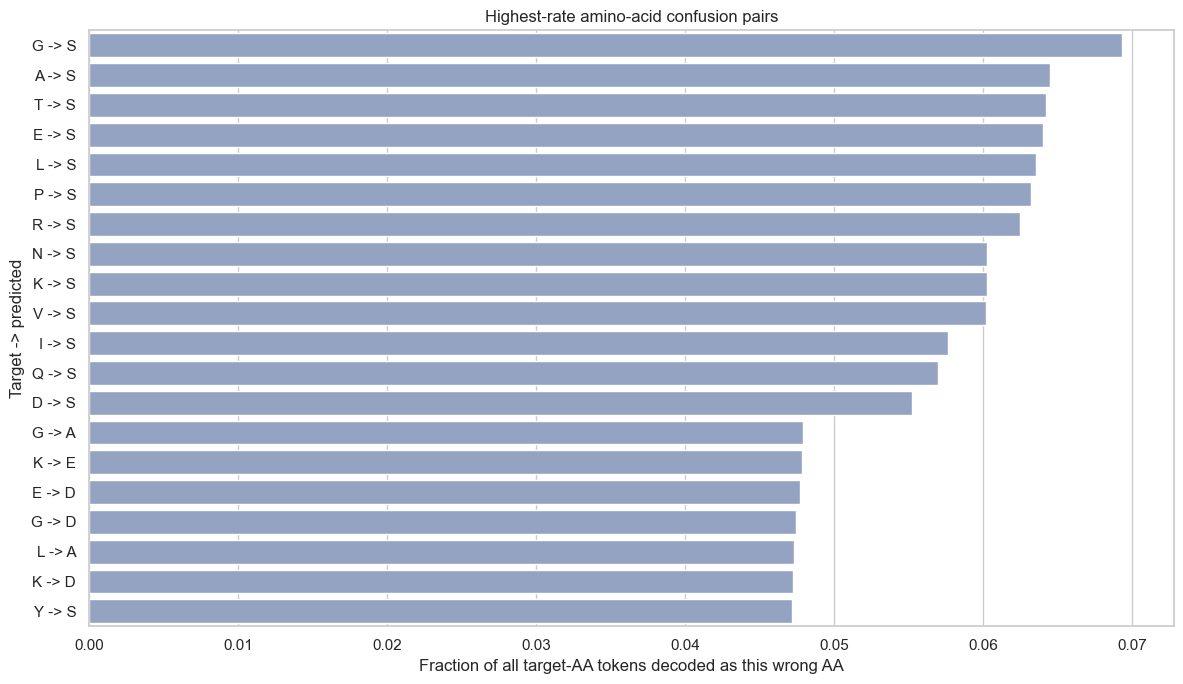

In [34]:
confusion_rate_matrix = pd.crosstab(
    aa_confusions["target_aa"],
    aa_confusions["predicted_aa"],
    normalize="index",
)
confusion_rate_matrix = confusion_rate_matrix.reindex(index=standard_aas, columns=standard_aas).fillna(0.0)

off_diagonal_matrix = confusion_rate_matrix.copy()
for aa in standard_aas:
    off_diagonal_matrix.loc[aa, aa] = 0.0

plt.figure(figsize=(12, 9))
sns.heatmap(
    off_diagonal_matrix,
    cmap="mako",
    vmin=0,
    cbar_kws={"label": "Fraction of target tokens decoded as predicted AA"},
)
plt.title("Off-diagonal amino-acid confusion rates")
plt.xlabel("Predicted amino acid")
plt.ylabel("Target amino acid")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_confusion_pairs.head(20),
    y="confusion_pair",
    x="rate_among_target_tokens",
    color="#8da0cb",
)
plt.title("Highest-rate amino-acid confusion pairs")
plt.xlabel("Fraction of all target-AA tokens decoded as this wrong AA")
plt.ylabel("Target -> predicted")
plt.tight_layout()
plt.show()

In [35]:
top_error_share_pairs = aa_pair_counts.sort_values(
    ["share_of_target_errors", "n_confusions"],
    ascending=False,
).head(25)

display(top_error_share_pairs[[
    "confusion_pair",
    "n_confusions",
    "target_count",
    "target_error_count",
    "rate_among_target_tokens",
    "share_of_target_errors",
]])

print(
    "Use rate_among_target_tokens to find high absolute-rate confusions. "
    "Use share_of_target_errors to see which wrong prediction dominates a target amino acid's mistakes."
)

,confusion_pair,n_confusions,target_count,target_error_count,rate_among_target_tokens,share_of_target_errors
255,P -> S,1735,27438,15024,0.063233,0.115482
275,Q -> S,1330,23337,12556,0.056991,0.105925
336,T -> S,2022,31469,19169,0.064254,0.105483
115,G -> S,2724,39276,26203,0.069355,0.103958
235,N -> S,1487,24664,14461,0.060290,0.102828
75,E -> S,2669,41705,27253,0.063997,0.097934
295,R -> S,2068,33105,21152,0.062468,0.097769
55,D -> S,1888,34182,19717,0.055234,0.095755
15,A -> S,3037,47069,31791,0.064522,0.095530
135,H -> S,817,19194,8627,0.042565,0.094703


Use rate_among_target_tokens to find high absolute-rate confusions. Use share_of_target_errors to see which wrong prediction dominates a target amino acid's mistakes.


## 6. Training History Curves

These curves compare checkpoint training histories. They are useful for checking whether a run is still improving, overfitting, diverging, or simply worse because the objective changed. The table reports the best validation-loss epoch for each history file.

In [36]:
history_records = []

for history_path in sorted(HISTORY_DIR.glob("**/*.json")):
    try:
        history = json.loads(history_path.read_text())
    except json.JSONDecodeError:
        continue

    history_name = str(history_path.relative_to(PROJECT_ROOT))
    hparams = history.get("hyperparameters", {})
    curriculum = history.get("curriculum", {})

    for epoch_record in history.get("epochs", []):
        history_records.append(
            {
                "history": history_name,
                "epoch": epoch_record.get("epoch"),
                "train_loss": epoch_record.get("train_loss"),
                "val_loss": epoch_record.get("val_loss"),
                "train_accuracy": epoch_record.get("train_accuracy"),
                "train_f1": epoch_record.get("train_f1"),
                "val_accuracy": epoch_record.get("val_accuracy"),
                "curriculum_fraction": epoch_record.get("curriculum_fraction"),
                "curriculum_examples": epoch_record.get("curriculum_examples"),
                "condition_decoder_on_latent": hparams.get("condition_decoder_on_latent"),
                "grad_clip": hparams.get("grad_clip"),
                "curriculum_type": curriculum.get("type", "unknown"),
            }
        )

history_df = pd.DataFrame(history_records)
history_df = history_df.replace([np.inf, -np.inf], np.nan)
numeric_history_cols = ["epoch", "train_loss", "val_loss", "train_accuracy", "train_f1", "val_accuracy"]
history_df[numeric_history_cols] = history_df[numeric_history_cols].apply(pd.to_numeric, errors="coerce")

solubility_ae_histories = [
    "history/solubility_ae_history.json",
    "history/v1/ae_v1_history.json",
    "history/v2/solubility_ae_history.json",
    "history/v3/solubility_ae_history.json",
    "history/v4/solubility_ae_history.json",
]
plot_history_df = history_df[history_df["history"].isin(solubility_ae_histories)].copy()
plot_history_df = plot_history_df.dropna(subset=["epoch"])

best_history_rows = []
for history_name, group in plot_history_df.dropna(subset=["val_loss"]).groupby("history"):
    best = group.loc[group["val_loss"].idxmin()]
    last = group.sort_values("epoch").iloc[-1]
    best_history_rows.append(
        {
            "history": history_name,
            "n_epochs": int(group["epoch"].max()),
            "best_epoch": int(best["epoch"]),
            "best_val_loss": best["val_loss"],
            "best_val_accuracy": best["val_accuracy"],
            "last_epoch": int(last["epoch"]),
            "last_val_loss": last["val_loss"],
            "last_val_accuracy": last["val_accuracy"],
            "condition_decoder_on_latent": last["condition_decoder_on_latent"],
            "curriculum_type": last["curriculum_type"],
        }
    )

best_history_df = pd.DataFrame(best_history_rows).sort_values("history")
display(best_history_df)

,history,n_epochs,best_epoch,best_val_loss,best_val_accuracy,last_epoch,last_val_loss,last_val_accuracy,condition_decoder_on_latent,curriculum_type
0,history/solubility_ae_history.json,31,30,1.629565,0.406386,31,1.677079,0.391463,True,length
1,history/v1/ae_v1_history.json,26,21,2.324400,0.265400,26,2.327000,0.263800,None,unknown
2,history/v2/solubility_ae_history.json,18,17,2.165478,0.303989,18,2.905450,0.094193,None,unknown
3,history/v3/solubility_ae_history.json,11,11,2.222754,0.284793,11,2.222754,0.284793,None,unknown
4,history/v4/solubility_ae_history.json,25,25,1.731282,0.376954,25,1.731282,0.376954,True,length


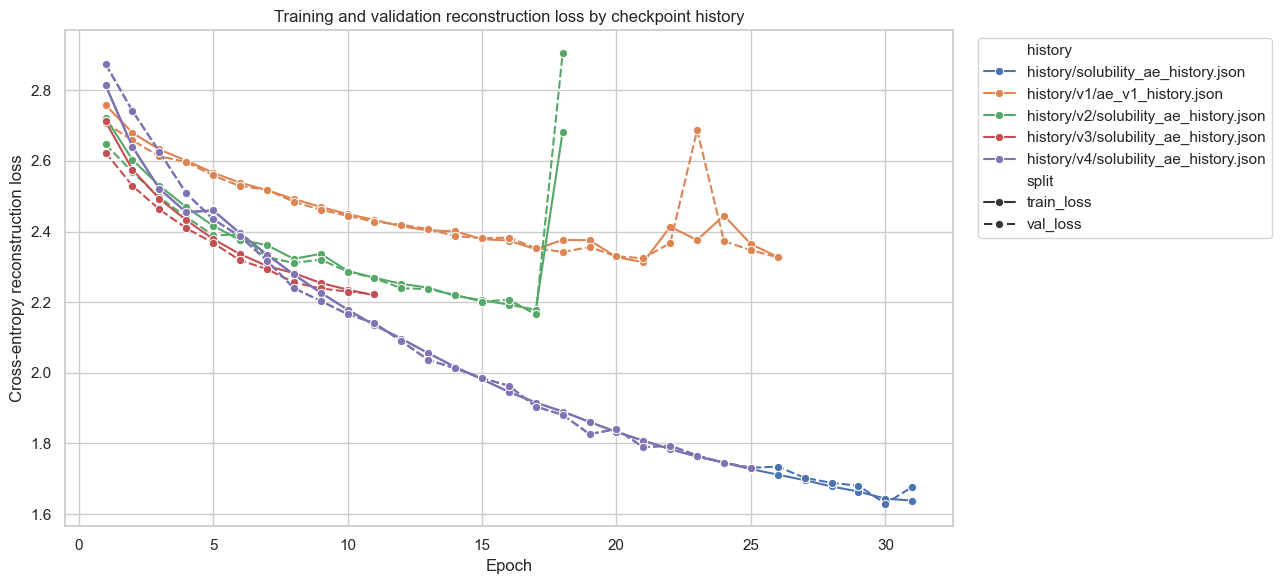

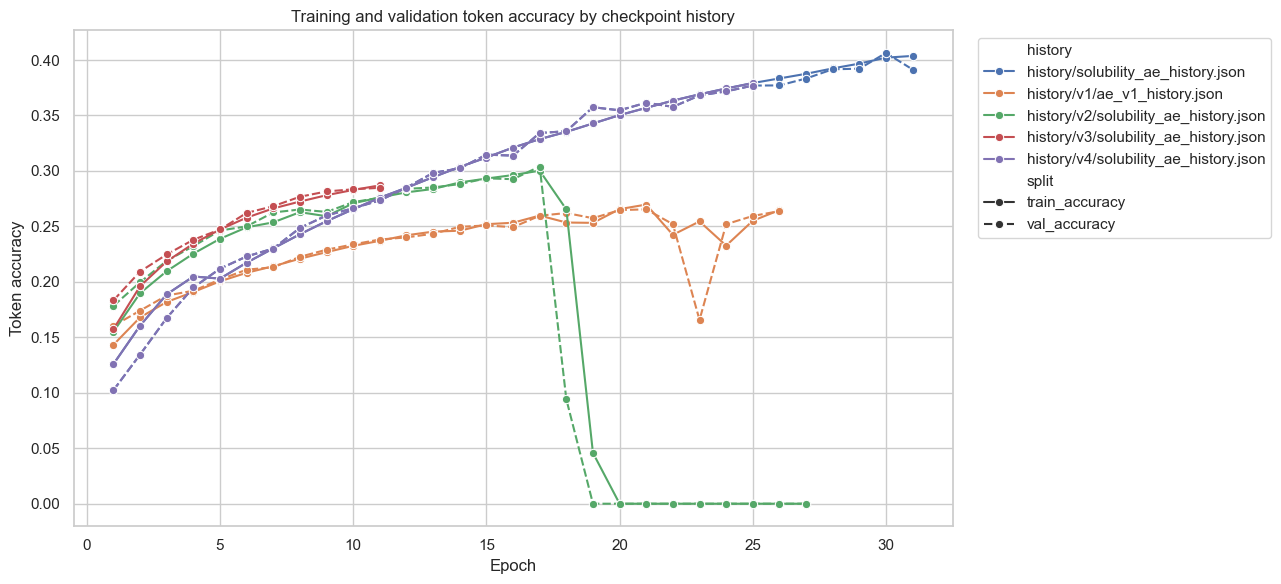

In [37]:
history_loss_long = plot_history_df.melt(
    id_vars=["history", "epoch"],
    value_vars=["train_loss", "val_loss"],
    var_name="split",
    value_name="loss",
).dropna(subset=["loss"])

plt.figure(figsize=(13, 6))
sns.lineplot(
    data=history_loss_long,
    x="epoch",
    y="loss",
    hue="history",
    style="split",
    marker="o",
)
plt.title("Training and validation reconstruction loss by checkpoint history")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy reconstruction loss")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

history_acc_long = plot_history_df.melt(
    id_vars=["history", "epoch"],
    value_vars=["train_accuracy", "val_accuracy"],
    var_name="split",
    value_name="accuracy",
).dropna(subset=["accuracy"])

plt.figure(figsize=(13, 6))
sns.lineplot(
    data=history_acc_long,
    x="epoch",
    y="accuracy",
    hue="history",
    style="split",
    marker="o",
)
plt.title("Training and validation token accuracy by checkpoint history")
plt.xlabel("Epoch")
plt.ylabel("Token accuracy")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

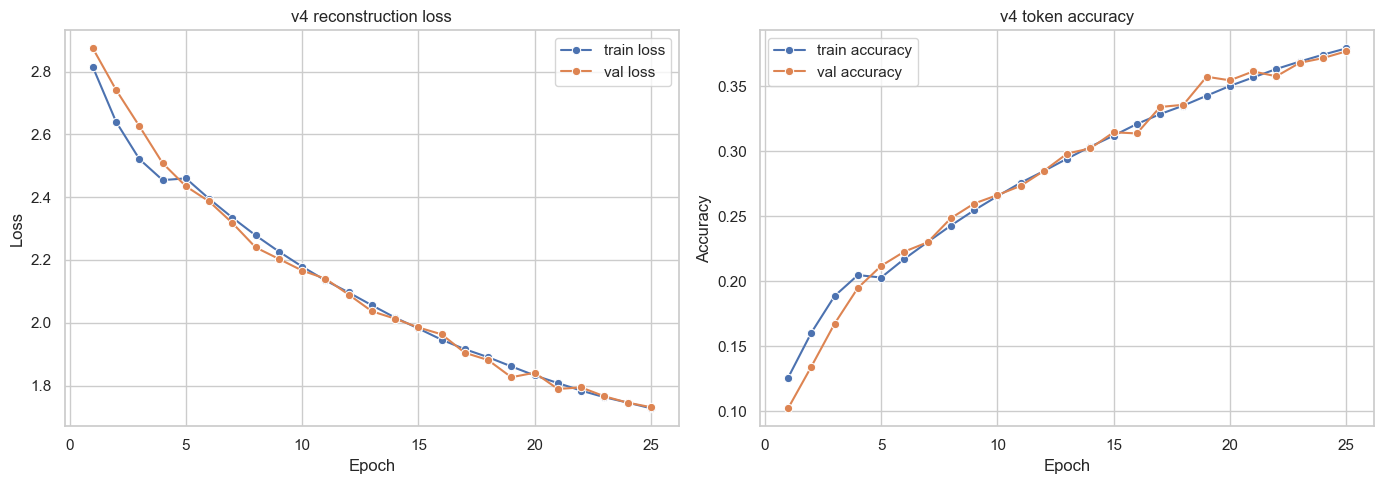

v4 epoch vs validation-loss Spearman rho=-0.998, p=2.12e-30


In [38]:
current_history_name = "history/v4/solubility_ae_history.json"
current_history_df = plot_history_df[plot_history_df["history"] == current_history_name].copy()

if current_history_df.empty:
    print(f"No rows found for {current_history_name}.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.lineplot(data=current_history_df, x="epoch", y="train_loss", marker="o", label="train loss", ax=axes[0])
    sns.lineplot(data=current_history_df, x="epoch", y="val_loss", marker="o", label="val loss", ax=axes[0])
    axes[0].set_title("v4 reconstruction loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")

    sns.lineplot(data=current_history_df, x="epoch", y="train_accuracy", marker="o", label="train accuracy", ax=axes[1])
    sns.lineplot(data=current_history_df, x="epoch", y="val_accuracy", marker="o", label="val accuracy", ax=axes[1])
    axes[1].set_title("v4 token accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")

    plt.tight_layout()
    plt.show()

    if current_history_df["val_loss"].notna().sum() >= 3:
        rho, p = stats.spearmanr(current_history_df["epoch"], current_history_df["val_loss"], nan_policy="omit")
        print(f"v4 epoch vs validation-loss Spearman rho={rho:.3f}, p={p:.3g}")